# Step 6: Isolation Forest (anomaly detection)

Goal: find **grid cell x week** combinations with unusual earthquake activity.

Input: `data/processed/quakes_clean.csv`.
Output: `models/isoforest.joblib`, `models/isoforest_features.json` (used by the
live demo in Step 10), `results/anomaly_metrics.csv`, `results/step6_*.csv`,
figures `figures/step6_*.png`.

**Rows:** cell-weeks with at least one earthquake (a week with no earthquake in
a cell has nothing to score; the live demo also scores only cells with new
events).

**Split by time, as in `config.py`:** the forest is fitted on 2000-2019 (no
labels are used to fit it), `contamination` is chosen on 2020-2022, and the
result is reported on 2023 onward, which the model has never seen.

**Evaluation without hand labels:** a cell-week that contains an M >= 7.0
earthquake counts as a true anomaly.

**Leakage check:** the true label is defined by magnitude, so magnitude
features make the result look better than it is. Three feature sets are run:

| set | features |
|---|---|
| A: with max magnitude | activity + mean and **max** magnitude |
| B: without max magnitude (plan) | activity + mean magnitude |
| C: activity only | no magnitude at all |

C is the honest test: can unusual *activity* alone point at big earthquakes?

In [1]:
import sys
sys.path.append("../scripts")
from config import *

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "font.size": 10,
})
for folder in (FIGURES_DIR, RESULTS_DIR, MODELS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / name, dpi=FIG_DPI, bbox_inches="tight")
    print("saved", FIGURES_DIR / name)

facts = []
def fact(item, value):
    facts.append({"item": item, "value": value})
    print(f"{item}: {value}")

TRUE_MAG = 7.0                                # a cell-week with M >= 7.0 is a true anomaly
CONTAMINATIONS = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
EARTH_KM = 6371.0088

## 1. Cell x week table

In [2]:
df = pd.read_csv(CLEAN_FILE, dtype={"id": str})
df["time"] = pd.to_datetime(df["time"], utc=True, format="ISO8601")
# week starting Monday, as a plain date
df["week"] = df["time"].dt.tz_localize(None).dt.to_period("W-SUN").dt.start_time

# distance of each event to the centre of its cell-week (how spread out the activity is)
g = df.groupby(["cell_id", "week"])
lat0, lon0 = g["latitude"].transform("mean"), g["longitude"].transform("mean")
la1, lo1, la2, lo2 = map(np.radians, (df["latitude"], df["longitude"], lat0, lon0))
a = np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2
df["km_to_centre"] = 2 * EARTH_KM * np.arcsin(np.sqrt(a))

cw = g.agg(n_events=("id", "size"), max_mag=("mag", "max"), mean_mag=("mag", "mean"),
           mean_depth=("depth", "mean"), spread_km=("km_to_centre", "mean")).reset_index()
cw["year"] = cw["week"].dt.year
cw["split"] = np.select([cw["week"] <= pd.Timestamp(TRAIN_END), cw["week"] <= pd.Timestamp(VAL_END)],
                        ["train", "val"], default="test")
cw["is_true_anomaly"] = (cw["max_mag"] >= TRUE_MAG).astype(int)

# normal weekly rate of each cell, from the training years only (no look into the future)
train_weeks = pd.date_range(df["week"].min(), pd.Timestamp(TRAIN_END), freq="W-MON").size
train_counts = df[df["week"] <= pd.Timestamp(TRAIN_END)].groupby("cell_id").size()
BASE_FLOOR = 1 / train_weeks                      # cells quiet in training: one event over the period
baseline = (train_counts / train_weeks).reindex(cw["cell_id"].unique()).fillna(BASE_FLOOR).clip(lower=BASE_FLOOR)
cw["rate_ratio"] = cw["n_events"] / cw["cell_id"].map(baseline)
cw["log_rate_ratio"] = np.log10(cw["rate_ratio"])

fact("cell-weeks with at least one earthquake", len(cw))
fact("grid cells", cw["cell_id"].nunique())
for s in ("train", "val", "test"):
    part = cw[cw["split"] == s]
    fact(f"{s} cell-weeks", len(part))
    fact(f"{s} true anomalies (M >= {TRUE_MAG})", int(part["is_true_anomaly"].sum()))
    fact(f"{s} true anomaly pct", round(part["is_true_anomaly"].mean() * 100, 3))
cw.describe().T[["mean", "50%", "max"]]

cell-weeks with at least one earthquake: 91350
grid cells: 1206
train cell-weeks: 66620
train true anomalies (M >= 7.0): 282
train true anomaly pct: 0.423
val cell-weeks: 11182
val true anomalies (M >= 7.0): 37
val true anomaly pct: 0.331
test cell-weeks: 13548
test true anomalies (M >= 7.0): 54
test true anomaly pct: 0.399


,mean,50%,max
week,2013-12-28 20:28:01.655172,2014-04-14 00:00:00,2026-10-05 00:00:00
n_events,2.05306,1.0,1008.0
max_mag,4.918186,4.8,9.1
mean_mag,4.810672,4.7,7.7
mean_depth,68.336608,33.0,680.5
spread_km,28.963612,0.0,334.418057
year,2013.493629,2014.0,2026.0
is_true_anomaly,0.004083,0.0,1.0
rate_ratio,20.565016,2.846119,12888.333333
log_rate_ratio,0.565339,0.454253,4.110197


## 2. Fit one forest per feature set (training years only)

In [3]:
ACTIVITY = ["n_events", "log_rate_ratio", "mean_depth", "spread_km"]
FEATURE_SETS = {
    "A: with max magnitude": ACTIVITY + ["mean_mag", "max_mag"],
    "B: without max magnitude": ACTIVITY + ["mean_mag"],
    "C: activity only": ACTIVITY,
}

train, val, test = (cw[cw["split"] == s] for s in ("train", "val", "test"))
models, scores = {}, {}
for name, feats in FEATURE_SETS.items():
    m = IsolationForest(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(train[feats])
    models[name] = m
    # higher = more anomalous
    scores[name] = pd.Series(-m.score_samples(cw[feats]), index=cw.index)
    print(f"fitted {name}: {feats}")

fitted A: with max magnitude: ['n_events', 'log_rate_ratio', 'mean_depth', 'spread_km', 'mean_mag', 'max_mag']


fitted B: without max magnitude: ['n_events', 'log_rate_ratio', 'mean_depth', 'spread_km', 'mean_mag']


fitted C: activity only: ['n_events', 'log_rate_ratio', 'mean_depth', 'spread_km']


## 3. Precision and recall

`contamination` = share of cell-weeks flagged. The cut-off score is taken from
the training years, so a contamination of 1% flags the cell-weeks more unusual
than 99% of the training ones. **Random guessing** has a precision equal to the
share of true anomalies; PR-AUC and ROC-AUC measure the ranking without any
cut-off.

In [4]:
def evaluate(name, c, part):
    s = scores[name]
    cut = np.quantile(s[train.index], 1 - c)
    y, flag = part["is_true_anomaly"].to_numpy(), (s[part.index] >= cut).to_numpy()
    tp = int((flag & (y == 1)).sum())
    prec = tp / flag.sum() if flag.sum() else 0.0
    rec = tp / y.sum() if y.sum() else np.nan
    return {"feature_set": name, "contamination": c, "flagged": int(flag.sum()), "true_positives": tp,
            "precision": round(prec, 3), "recall": round(rec, 3),
            "f1": round(2 * prec * rec / (prec + rec), 3) if prec + rec else 0.0,
            "random_precision": round(y.mean(), 4),
            "lift_vs_random": round(prec / y.mean(), 1) if y.mean() else np.nan,
            "pr_auc": round(average_precision_score(y, s[part.index]), 3),
            "roc_auc": round(roc_auc_score(y, s[part.index]), 3), "cut_score": round(cut, 4)}

rows = []
for split_name, part in (("val", val), ("test", test)):
    for name in FEATURE_SETS:
        for c in CONTAMINATIONS:
            rows.append({"split": split_name, **evaluate(name, c, part)})
metrics = pd.DataFrame(rows)

# contamination chosen on the validation years (best F1 of the plan's set B), then used everywhere
CHOSEN = float(metrics[(metrics["split"] == "val") & (metrics["feature_set"] == "B: without max magnitude")]
               .sort_values(["f1", "contamination"], ascending=[False, True]).iloc[0]["contamination"])
metrics["chosen"] = metrics["contamination"] == CHOSEN
metrics.to_csv(RESULTS_DIR / "anomaly_metrics.csv", index=False)
fact("chosen contamination (best validation F1, set B)", CHOSEN)

report = metrics[(metrics["split"] == "test") & metrics["chosen"]].set_index("feature_set")
for name, r in report.iterrows():
    key = name.split(":")[0]
    fact(f"test precision {key}", r["precision"])
    fact(f"test recall {key}", r["recall"])
    fact(f"test PR-AUC {key}", r["pr_auc"])
    fact(f"test lift vs random {key}", r["lift_vs_random"])
fact("test random precision", report["random_precision"].iloc[0])
report[["flagged", "true_positives", "precision", "recall", "f1", "random_precision",
        "lift_vs_random", "pr_auc", "roc_auc"]]

chosen contamination (best validation F1, set B): 0.002
test precision A: 0.759
test recall A: 0.407
test PR-AUC A: 0.601
test lift vs random A: 190.3
test precision B: 0.424
test recall B: 0.259
test PR-AUC B: 0.274
test lift vs random B: 106.4
test precision C: 0.485
test recall C: 0.296
test PR-AUC C: 0.244
test lift vs random C: 121.6
test random precision: 0.004


,flagged,true_positives,precision,recall,f1,random_precision,lift_vs_random,pr_auc,roc_auc
feature_set,,,,,,,,,
A: with max magnitude,29,22,0.759,0.407,0.530,0.004,190.3,0.601,0.995
B: without max magnitude,33,14,0.424,0.259,0.322,0.004,106.4,0.274,0.971
C: activity only,33,16,0.485,0.296,0.368,0.004,121.6,0.244,0.921


saved C:\Users\user\Documents\assignment\earthquake_project\figures\step6_metrics.png


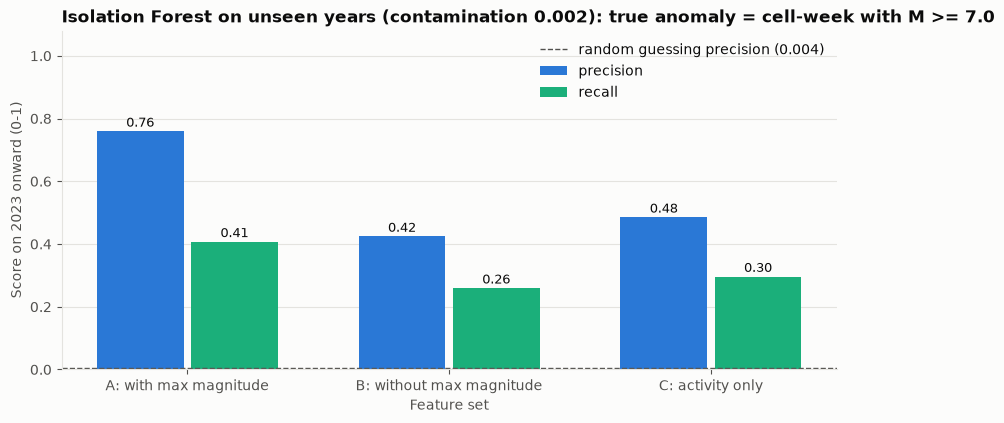

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.4))
names = list(FEATURE_SETS)
x = np.arange(len(names))
w = 0.36
for k, (col, color, label) in enumerate((("precision", BLUE, "precision"), ("recall", AQUA, "recall"))):
    vals = report.loc[names, col].to_numpy()
    bars = ax.bar(x + (k - 0.5) * w, vals, width=w * 0.92, color=color, label=label)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.2f}", ha="center", fontsize=9.5, color=INK)
rp = report["random_precision"].iloc[0]
ax.axhline(rp, color=MUTED, lw=1, ls="--", label=f"random guessing precision ({rp:.3f})")
ax.set_xticks(x, names)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score on 2023 onward (0-1)")
ax.set_xlabel("Feature set")
ax.set_title(f"Isolation Forest on unseen years (contamination {CHOSEN:g}): "
             f"true anomaly = cell-week with M >= {TRUE_MAG}", fontsize=12)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
save_fig(fig, "step6_metrics.png")
plt.show()

## 4. Anomaly timeline on the unseen years (set B)

Blue: the highest anomaly score of each week (over all cells), 2023 onward.
Orange: every cell-week with an M >= 7.0 earthquake, at **its own** score;
filled = flagged by the model (score above the cut-off), hollow = missed.

saved C:\Users\user\Documents\assignment\earthquake_project\figures\step6_anomaly_timeline.png


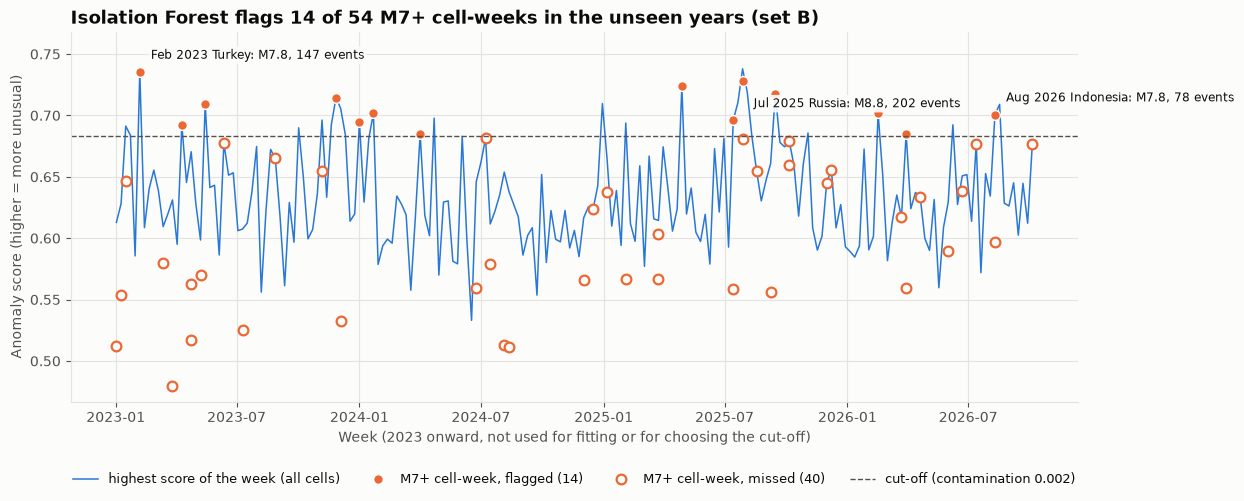

In [6]:
MAIN = "B: without max magnitude"
cw["score"] = scores[MAIN]
cut = float(np.quantile(cw.loc[train.index, "score"], 1 - CHOSEN))
cw["flagged"] = (cw["score"] >= cut).astype(int)
cw[["cell_id", "week", "split", "n_events", "rate_ratio", "mean_mag", "max_mag", "score", "flagged",
    "is_true_anomaly"]].to_csv(RESULTS_DIR / "step6_cell_week_scores.csv", index=False)

tc = cw[cw["split"] == "test"]
weekly = tc.groupby("week")["score"].max()
pos = tc[tc["is_true_anomaly"] == 1]
caught, missed = pos[pos["flagged"] == 1], pos[pos["flagged"] == 0]

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(weekly.index, weekly.values, color=BLUE, lw=1.1, label="highest score of the week (all cells)")
ax.plot(caught["week"], caught["score"], "o", ms=7, color=ORANGE, mec=SURFACE, mew=1, ls="",
        label=f"M7+ cell-week, flagged ({len(caught)})")
ax.plot(missed["week"], missed["score"], "o", ms=7, mfc=SURFACE, mec=ORANGE, mew=1.6, ls="",
        label=f"M7+ cell-week, missed ({len(missed)})")
ax.axhline(cut, color=MUTED, lw=1, ls="--", label=f"cut-off (contamination {CHOSEN:g})")
for k, (_, r) in enumerate(caught.nlargest(3, "max_mag").sort_values("week").iterrows()):
    reg = df.loc[(df["cell_id"] == r["cell_id"]) & (df["week"] == r["week"]), "region"].mode().iloc[0]
    ax.annotate(f"{r['week']:%b %Y} {reg}: M{r['max_mag']:.1f}, {r['n_events']} events",
                (r["week"], r["score"]), xytext=(8, 12 if k % 2 == 0 else -16), textcoords="offset points",
                fontsize=8.5, va="center", color=INK,
                bbox={"boxstyle": "round,pad=0.2", "fc": SURFACE, "ec": "none", "alpha": 0.9})
ax.set_ylim(top=weekly.max() + 0.03)
ax.set_xlabel("Week (2023 onward, not used for fitting or for choosing the cut-off)")
ax.set_ylabel("Anomaly score (higher = more unusual)")
ax.set_title(f"Isolation Forest flags {len(caught)} of {len(pos)} M7+ cell-weeks in the unseen years (set B)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4, frameon=False, fontsize=9)
save_fig(fig, "step6_anomaly_timeline.png")
plt.show()

## 5. Save the model for the live demo (Step 10)

In [7]:
joblib.dump(models[MAIN], MODELS_DIR / "isoforest.joblib")
spec = {
    "feature_set": MAIN,
    "features": FEATURE_SETS[MAIN],
    "contamination": CHOSEN,
    "cut_score": round(cut, 6),
    "score": "anomaly score = -IsolationForest.score_samples(X); flag when score >= cut_score",
    "week": "Monday-start week of the event time (UTC)",
    "rate_ratio": "n_events / baseline_weekly_rate[cell_id]; log_rate_ratio = log10(rate_ratio)",
    "spread_km": "mean haversine distance (km) of the week's events to their mean lat/lon",
    "baseline_floor": BASE_FLOOR,
    "baseline_weekly_rate": {k: round(float(v), 6) for k, v in baseline.items()},
    "trained_on": f"cell-weeks up to {TRAIN_END}",
}
with open(MODELS_DIR / "isoforest_features.json", "w", encoding="utf-8") as f:
    json.dump(spec, f, indent=1)
print("saved", MODELS_DIR / "isoforest.joblib", "and isoforest_features.json")

# check: reloading gives the same scores
m2 = joblib.load(MODELS_DIR / "isoforest.joblib")
assert np.allclose(-m2.score_samples(cw[spec["features"]].head(1000)), cw["score"].head(1000))

saved C:\Users\user\Documents\assignment\earthquake_project\models\isoforest.joblib and isoforest_features.json


## 6. Save the facts

In [8]:
pd.DataFrame(facts).to_csv(RESULTS_DIR / "step6_facts.csv", index=False)
print(f"saved {RESULTS_DIR / 'step6_facts.csv'} ({len(facts)} items)")

saved C:\Users\user\Documents\assignment\earthquake_project\results\step6_facts.csv (25 items)


## 7. Observations

1. **The leak is real and large.** On the unseen years (2023 onward) the set with
   max magnitude reaches PR-AUC 0.60, the plan's set B 0.27 and the activity-only
   set C 0.24. Using max magnitude roughly doubles the score because it is the
   same number that defines the true label, so the slides report set B and C.
2. **Unusual activity does point at big earthquakes.** Random guessing would be
   right 0.4% of the time (54 true anomalies in 13,548 cell-weeks). Set B flags
   33 cell-weeks and 14 are M7+ (precision 0.42, about 106 times random);
   set C, with no magnitude at all, 16 of 33 (0.48, about 122 times random).
3. **What it catches is the aftershock burst, not the earthquake in advance.**
   The M7+ cell-weeks it flags have a median of 81.5 earthquakes in that week;
   the 40 it misses have a median of 8.5. A big earthquake with a small
   sequence looks like a normal week. This is detection after the fact, which
   suits a live monitor (Step 10), not a forecast (that is Step 8's job).
4. **The cut-off was chosen without looking at the test years.** Contamination
   0.002 had the best F1 on 2020-2022 (0.001 and 0.005 were worse there). On the
   test years 0.005 would score higher (F1 0.36 vs 0.32), but picking it now
   would be tuning on the test set, so 0.002 is kept and reported.
5. **Recall stays low (0.26 for set B):** most M7+ weeks are missed at this
   cut-off. Raising contamination to 0.01 lifts recall to 0.56 but drops
   precision to 0.23; the full trade-off is in `results/anomaly_metrics.csv`.

**Limitations:** weeks are fixed calendar weeks, so a sequence that starts late
in a week is split across two rows; 5-degree cells mix very active and quiet
areas; the model file is not in git (`models/*.joblib` is ignored), so run this
notebook once before the live demo.